# 라이브러리 임포트

In [1]:

import os
import torch
import itertools
os.environ['TORCH'] = torch.__version__
os.environ['PYTHONWARNINGS'] = "ignore"
!pip install torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install git+https://github.com/pyg-team/pytorch_geometric.git
!pip install torch-geometric
!pip3 install kmeans1d
from torch_geometric.data import HeteroData
from torch_sparse import matmul
import torch.nn.functional as F
from torch.nn import Linear
import torch_geometric.transforms as T
from torch_geometric.nn import SAGEConv, to_hetero
from torch_geometric.utils import structured_negative_sampling
from torch_geometric.nn.conv.gcn_conv import gcn_norm # Corrected import path for gcn_norm
import sys
import random
import numpy as np
import time
import math
import csv
import datetime
import math
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import pandas as pd
import glob
import random
import torch.nn as nn
import torch.optim as optim
from collections import defaultdict
from tqdm.notebook import tqdm
from math import exp
from chardet import detect
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.utils import degree
from sklearn import preprocessing as pp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import scipy.sparse as sp
import networkx as nx
from networkx.algorithms import bipartite
import kmeans1d
import copy
from google.colab import drive
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score

Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu126.html
  Cloning https://github.com/pyg-team/pytorch_geometric.git to /tmp/pip-req-build-_u7geo26
  Running command git clone --filter=blob:none --quiet https://github.com/pyg-team/pytorch_geometric.git /tmp/pip-req-build-_u7geo26
  Resolved https://github.com/pyg-team/pytorch_geometric.git to commit 6208605b4d9711b86c7f06031b17efc5ea445afb
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# =========================
# 🔒 재현성을 위한 시드 고정
# =========================
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
# =========================

In [3]:
# 기본 설정 (Colab T4 GPU 환경 최적화)
# Colab 런타임에서 'T4 GPU' 사용을 전제로 'cuda' 장치를 명시적으로 설정합니다.
# 'cuda'를 사용할 수 없는 경우(예: GPU 런타임이 아닌 경우) 오류가 발생할 수 있으므로,
# Colab의 '런타임' > '런타임 유형 변경'에서 'T4 GPU'가 선택되었는지 확인하세요.

device = torch.device('cuda')

if torch.cuda.is_available():
    print(f"Using device: {device} ({torch.cuda.get_device_name(0)})")
else:
    print("--- 경고 (WARNING) ---")
    print("torch.cuda.is_available()가 False를 반환했습니다.")
    print("Colab 런타임이 'T4 GPU'로 설정되었는지 확인하세요.")
    print("CPU로 강제 전환을 시도합니다. (학습 속도가 매우 느릴 수 있습니다.)")
    device = torch.device('cpu')
    print(f"Using device: {device}")

Using device: cuda (Tesla T4)


# 데이터 로드 및 정제

--- 원본 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105139 entries, 0 to 105138
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   user    105139 non-null  int64  
 1   item    105139 non-null  int64  
 2   rating  105139 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 2.4 MB

--- 원본 데이터 통계 ---
                user           item         rating
count  105139.000000  105139.000000  105139.000000
mean      365.067178   13388.249841       3.517049
std       197.388251   26178.083791       1.044640
min         1.000000       1.000000       0.500000
25%       192.000000    1077.000000       3.000000
50%       383.000000    2498.000000       3.500000
75%       557.000000    5992.000000       4.000000
max       668.000000  149532.000000       5.000000

고유 사용자 수 (Raw): 668
고유 아이템(영화) 수 (Raw): 10321
총 상호작용 수 (Raw): 105139
데이터 희소성 (Sparsity): 98.4750%


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


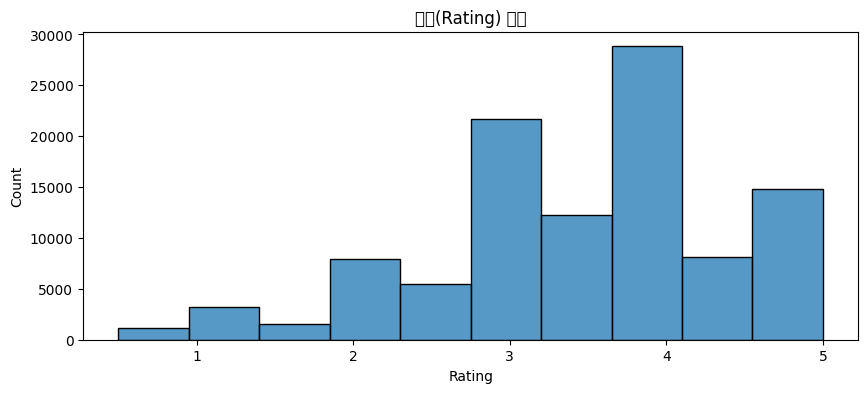

In [4]:
# 데이터 로드
df_train_raw = pd.read_csv("train.csv")

print("--- 원본 데이터 정보 ---")
df_train_raw.info()

print("\n--- 원본 데이터 통계 ---")
print(df_train_raw.describe())

# 고유 사용자 및 아이템 수
n_users_raw = df_train_raw['user'].nunique()
n_items_raw = df_train_raw['item'].nunique()
n_interactions_raw = len(df_train_raw)

# 희소성 계산
sparsity = 1.0 - (n_interactions_raw / (n_users_raw * n_items_raw))

print(f"\n고유 사용자 수 (Raw): {n_users_raw}")
print(f"고유 아이템(영화) 수 (Raw): {n_items_raw}")
print(f"총 상호작용 수 (Raw): {n_interactions_raw}")
print(f"데이터 희소성 (Sparsity): {sparsity * 100:.4f}%")

# 평점 분포 시각화
plt.figure(figsize=(10, 4))
sns.histplot(df_train_raw['rating'], bins=10, kde=False)
plt.title('평점(Rating) 분포')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [5]:
POSITIVE_THRESHOLD = 4.0
K_CORE = 10

# 1. 이진화: 4.0 이상 평점만 긍정적 상호작용으로 간주
df_implicit = df_train_raw[df_train_raw['rating'] >= POSITIVE_THRESHOLD].copy()
print(f"--- 1. 이진화 (Rating >= {POSITIVE_THRESHOLD}) ---")
print(f"긍정적 상호작용 수: {len(df_implicit)}")
print(f"긍정적 상호작용 비율: {len(df_implicit) / n_interactions_raw * 100:.2f}%")

# (코드 수정) 20% 쿼터 계산을 위해, K-Core 필터링 *전*의
# 원본 긍정 상호작용(구매 이력) 수를 사용자별로 계산
user_purchase_counts = df_implicit.groupby('user').size()
print(f"\n--- 쿼터 기준 생성 (K-Core 적용 전) ---")
print("사용자별 긍정 상호작용(구매) 수 (상위 5명):")
print(user_purchase_counts.sort_values(ascending=False).head())


# 2. K-Core 필터링 함수 정의
def k_core_filtering(df, k):
    """
    K-Core 필터링을 반복적으로 수행하여 k개 미만의 상호작용을 가진
    사용자와 아이템을 제거합니다. [3, 4, 70, 7, 5, 41, 69, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80]
    """
    print(f"\n--- 2. K-Core 필터링 (k={k}) 시작 ---")
    df_filtered = df.copy()
    while True:
        # 현재 유효한 사용자/아이템 수
        initial_users = df_filtered['user'].nunique()
        initial_items = df_filtered['item'].nunique()

        # k개 미만 상호작용을 가진 사용자 필터링
        user_counts = df_filtered.groupby('user').size()
        valid_users = user_counts[user_counts >= k].index
        df_filtered = df_filtered[df_filtered['user'].isin(valid_users)]

        # k개 미만 상호작용을 가진 아이템 필터링
        item_counts = df_filtered.groupby('item').size()
        valid_items = item_counts[item_counts >= k].index
        df_filtered = df_filtered[df_filtered['item'].isin(valid_items)]

        # 수렴 확인
        final_users = df_filtered['user'].nunique()
        final_items = df_filtered['item'].nunique()

        print(f"필터링 중... Users: {initial_users} -> {final_users}, Items: {initial_items} -> {final_items}")

        if initial_users == final_users and initial_items == final_items:
            break

    print(f"K-Core 필터링 완료.")
    return df_filtered

# K-Core 필터링 수행
df_filtered = k_core_filtering(df_implicit, k=K_CORE)

# 정제 후 데이터 통계
n_users_filtered = df_filtered['user'].nunique()
n_items_filtered = df_filtered['item'].nunique()
n_interactions_filtered = len(df_filtered)
sparsity_filtered = 1.0 - (n_interactions_filtered / (n_users_filtered * n_items_filtered))

print("\n--- 데이터 정제 결과 비교 ---")
stats_data = {
    'Metric': ['고유 사용자 수', '고유 아이템 수', '총 상호작용 수', '데이터 희소성 (%)'],
    'Before (Raw)': [n_users_raw, n_items_raw, n_interactions_raw, f"{sparsity * 100:.4f}%"],
    'After (Filtered)': [n_users_filtered, n_items_filtered, n_interactions_filtered, f"{sparsity_filtered * 100:.4f}%"]
}
stats_df = pd.DataFrame(stats_data)
print(stats_df.to_markdown(index=False))

# (코드 추가) Bipartite=False 문제의 원인 확인
users_check = set(df_filtered['user'].unique())
items_check = set(df_filtered['item'].unique())
overlap = users_check.intersection(items_check)
if overlap:
    print(f"\n[경고] User ID와 Item ID 간에 {len(overlap)}개의 중복 ID가 발견되었습니다 (예: {list(overlap)[:5]}).")
    print("NetworkX 그래프 생성 시, ID를 분리하여 Bipartite=True를 보장합니다.")

--- 1. 이진화 (Rating >= 4.0) ---
긍정적 상호작용 수: 51830
긍정적 상호작용 비율: 49.30%

--- 쿼터 기준 생성 (K-Core 적용 전) ---
사용자별 긍정 상호작용(구매) 수 (상위 5명):
user
668    969
458    964
232    884
575    781
109    645
dtype: int64

--- 2. K-Core 필터링 (k=10) 시작 ---
필터링 중... Users: 668 -> 632, Items: 6280 -> 1245
필터링 중... Users: 632 -> 606, Items: 1245 -> 1239
필터링 중... Users: 606 -> 606, Items: 1239 -> 1239
K-Core 필터링 완료.

--- 데이터 정제 결과 비교 ---
| Metric            | Before (Raw)   | After (Filtered)   |
|:------------------|:---------------|:-------------------|
| 고유 사용자 수    | 668            | 606                |
| 고유 아이템 수    | 10321          | 1239               |
| 총 상호작용 수    | 105139         | 38484              |
| 데이터 희소성 (%) | 98.4750%       | 94.8745%           |

[경고] User ID와 Item ID 간에 173개의 중복 ID가 발견되었습니다 (예: [np.int64(1), np.int64(2), np.int64(3), np.int64(515), np.int64(5)]).
NetworkX 그래프 생성 시, ID를 분리하여 Bipartite=True를 보장합니다.


# 이분 그래프

In [6]:
# (코드 수정) PyG와 NetworkX에서 사용할 원본 ID 리스트 정의
#.unique()는 원본 순서를 보장하므로 users, items 변수명으로 재사용
users = df_filtered['user'].unique()
items = df_filtered['item'].unique()

# NetworkX 이분 그래프 생성
B = nx.Graph()

# (코드 수정) NetworkX의 Bipartite=False 오류 해결을 위해
# 아이템 노드 ID를 "i_" 접두사를 붙여 고유하게 만듭니다.
users_nx = users
items_nx_disjoint = [f"i_{item}" for item in items]

# 1. 노드 추가 (bipartite=0은 사용자, bipartite=1은 아이템) [7]
B.add_nodes_from(users_nx, bipartite=0, label='user')
B.add_nodes_from(items_nx_disjoint, bipartite=1, label='item')

# 2. 엣지 추가 (아이템 ID에 접두사 "i_" 적용)
edges_nx = [(row['user'], f"i_{row['item']}") for _, row in df_filtered.iterrows()]
B.add_edges_from(edges_nx)

print("--- NetworkX Bipartite Graph 정보 ---")
print(f"그래프가 Bipartite 입니까? {nx.is_bipartite(B)}") # True로 수정됨
print(f"총 노드 수: {B.number_of_nodes()}")
print(f"총 엣지 수: {B.number_of_edges()}")

--- NetworkX Bipartite Graph 정보 ---
그래프가 Bipartite 입니까? True
총 노드 수: 3084
총 엣지 수: 38484


In [7]:
print("\n--- 1. Bipartite Centrality 계산 (NetworkX) ---")
# (코드 수정) NetworkX의 disjoint node set (users_nx, items_nx_disjoint)을 사용
# Degree Centrality (Bipartite)
user_deg_cent = bipartite.degree_centrality(B, users_nx)
item_deg_cent = bipartite.degree_centrality(B, items_nx_disjoint)

# Betweenness Centrality (Bipartite)
# (계산에 시간이 다소 소요될 수 있습니다)
user_bet_cent = bipartite.betweenness_centrality(B, users_nx)
item_bet_cent = bipartite.betweenness_centrality(B, items_nx_disjoint)

print("Centrality 계산 완료.")

# --- 2. 특성 DataFrame 생성 및 필터링 (오류 수정 핵심) ---

# [사용자 특성]
# 딕셔너리에는 모든 노드가 섞여 있으므로, users(정수 ID)만 뽑아냅니다.
user_features_df = pd.DataFrame.from_dict(user_deg_cent, orient='index', columns=['degree'])
user_features_df['betweenness'] = pd.Series(user_bet_cent)
# 핵심: 사용자 ID만 남기고, 결측치는 0으로 채움
user_features_df = user_features_df.reindex(users).fillna(0)

# [아이템 특성]
item_features_df = pd.DataFrame.from_dict(item_deg_cent, orient='index', columns=['degree'])
item_features_df['betweenness'] = pd.Series(item_bet_cent)

# 핵심 수정: ID 변환 전에 'i_...' 형태의 아이템 노드만 먼저 필터링합니다.
# 이렇게 하면 정수형 사용자 ID가 제거되어 IndexError가 발생하지 않습니다.
item_features_df = item_features_df.reindex(items_nx_disjoint).fillna(0)

# 3. 아이템 ID 복원 (접두사 "i_" 제거)
# 이제 인덱스에는 문자열만 남아있으므로 안전하게 변환 가능합니다.
# float() 처리로 ".0" 등이 붙은 경우도 대비합니다.
item_features_df.index = item_features_df.index.map(lambda x: int(float(x[2:])))

print("\n--- 3. K-Means 클러스터링으로 특성 추가 [1] ---")
# 특성 스케일링
scaler = StandardScaler()
user_features_scaled = scaler.fit_transform(user_features_df)
item_features_scaled = scaler.fit_transform(item_features_df)

# K-Means (사용자 5개 그룹, 아이템 5개 그룹으로 군집화)
kmeans_user = KMeans(n_clusters=5, random_state=42, n_init=10)
user_features_df['cluster'] = kmeans_user.fit_predict(user_features_scaled)

kmeans_item = KMeans(n_clusters=5, random_state=42, n_init=10)
item_features_df['cluster'] = kmeans_item.fit_predict(item_features_scaled)

# K-Means 결과를 One-Hot Encoding하여 GNN이 쉽게 학습하도록 변환
user_features_final = pd.get_dummies(user_features_df, columns=['cluster'], prefix='cluster')
item_features_final = pd.get_dummies(item_features_df, columns=['cluster'], prefix='cluster')

print("사용자 특성 샘플 (NetworkX + K-Means):")
print(user_features_final.head())
print("\n아이템 특성 샘플 (NetworkX + K-Means):")
print(item_features_final.head())


--- 1. Bipartite Centrality 계산 (NetworkX) ---
Centrality 계산 완료.

--- 3. K-Means 클러스터링으로 특성 추가 [1] ---
사용자 특성 샘플 (NetworkX + K-Means):
     degree  betweenness  cluster_0  cluster_1  cluster_2  cluster_3  \
1  0.024213     0.000154      False      False      False       True   
2  0.006860     0.000020      False       True      False      False   
3  0.014124     0.000090      False       True      False      False   
4  0.030266     0.000363      False      False      False       True   
5  0.005246     0.000011      False       True      False      False   

   cluster_4  
1      False  
2      False  
3      False  
4      False  
5      False  

아이템 특성 샘플 (NetworkX + K-Means):
     degree  betweenness  cluster_0
16      0.0          0.0       True
32      0.0          0.0       True
47      0.0          0.0       True
50      0.0          0.0       True
110     0.0          0.0       True


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


# 파이프라인 구축

In [8]:
# 1. ID Mapping 생성 (원본 ID 사용)
# User ID 맵핑
user_ids_mapped = {user_id: i for i, user_id in enumerate(users)}
# Item ID 맵핑
item_ids_mapped = {item_id: i for i, item_id in enumerate(items)}

# 2. 특성 텐서 생성 (맵핑 순서에 맞게) - [수정됨]
# reindex로 인해 발생하는 NaN 값을 0으로 채우고, 강제로 float32 numpy 배열로 변환합니다.
user_features_tensor = torch.tensor(
    user_features_final.reindex(users).fillna(0).values.astype(np.float32),
    dtype=torch.float32
)
item_features_tensor = torch.tensor(
    item_features_final.reindex(items).fillna(0).values.astype(np.float32),
    dtype=torch.float32
)
# 3. 엣지 인덱스 생성 (맵핑된 ID 사용)
edge_index_user = torch.tensor(
    [user_ids_mapped[u] for u in df_filtered['user']], dtype=torch.long
)
edge_index_item = torch.tensor(
    [item_ids_mapped[i] for i in df_filtered['item']], dtype=torch.long
)
edge_index = torch.stack([edge_index_user, edge_index_item], dim=0)

# 4. HeteroData 객체 생성 [40, 42]
data = HeteroData()
data['user'].num_nodes = len(users)
data['item'].num_nodes = len(items)
data['user'].x = user_features_tensor  # 2단계에서 생성한 특성 할당
data['item'].x = item_features_tensor  # 2단계에서 생성한 특성 할당
data['user', 'rates', 'item'].edge_index = edge_index

print("\n--- PyG HeteroData 객체 ---")
print(data)


--- PyG HeteroData 객체 ---
HeteroData(
  user={
    num_nodes=606,
    x=[606, 7],
  },
  item={
    num_nodes=1239,
    x=[1239, 3],
  },
  (user, rates, item)={ edge_index=[2, 38484] }
)


In [9]:
# 1. 양방향 엣지 생성
# 'item' -> 'user' 엣지 (rev_rates) 자동 생성
data = T.ToUndirected()(data)

# 2. (코드 수정) 전체 그래프 데이터를 GPU로 이동
data = data.to(device)
print(f"\n--- 양방향 변환 후 HeteroData (on {device}) ---")
print(data)

# 3. 학습/검증/테스트 데이터 분할 (Link Prediction Task)
# T.RandomLinkSplit은 edge_label (정답)과 edge_label_index (예측 대상 엣지)를 자동으로 생성
# BPR을 위해 네거티브 샘플링은 수동으로 할 것이므로 add_negative_train_samples=False 설정
transform = T.RandomLinkSplit(
    is_undirected=True,         # 그래프가 양방향임을 명시
    num_val=0.1,                # 검증용 엣지 10%
    num_test=0.1,               # 테스트용 엣지 10%
    neg_sampling_ratio=1.0,     # 1:1 비율로 네거티브 샘플링 (val, test용)
    add_negative_train_samples=False, # 학습용 네거티브 샘플은 BPR에서 직접 처리
    edge_types=[('user', 'rates', 'item')],
    rev_edge_types=[('item', 'rev_rates', 'user')]
)

train_data, val_data, test_data = transform(data)

print("\n--- 분할된 학습 데이터 (train_data) ---")
print(train_data)
print("\n--- 분할된 검증 데이터 (val_data) ---")
print(val_data)


--- 양방향 변환 후 HeteroData (on cuda) ---
HeteroData(
  user={
    num_nodes=606,
    x=[606, 7],
  },
  item={
    num_nodes=1239,
    x=[1239, 3],
  },
  (user, rates, item)={ edge_index=[2, 38484] },
  (item, rev_rates, user)={ edge_index=[2, 38484] }
)

--- 분할된 학습 데이터 (train_data) ---
HeteroData(
  user={
    num_nodes=606,
    x=[606, 7],
  },
  item={
    num_nodes=1239,
    x=[1239, 3],
  },
  (user, rates, item)={
    edge_index=[2, 30788],
    edge_label=[30788],
    edge_label_index=[2, 30788],
  },
  (item, rev_rates, user)={ edge_index=[2, 30788] }
)

--- 분할된 검증 데이터 (val_data) ---
HeteroData(
  user={
    num_nodes=606,
    x=[606, 7],
  },
  item={
    num_nodes=1239,
    x=[1239, 3],
  },
  (user, rates, item)={
    edge_index=[2, 30788],
    edge_label=[7696],
    edge_label_index=[2, 7696],
  },
  (item, rev_rates, user)={ edge_index=[2, 30788] }
)


# GNN모델 설계

In [10]:
# GraphSAGE 모델 정의
HIDDEN_CHANNELS = 128
OUT_CHANNELS = 64

class GNNEncoder(torch.nn.Module):
    """
    SAGEConv를 2번 쌓은 GNN 인코더
    """
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv((-1, -1), hidden_channels)
        self.conv2 = SAGEConv((-1, -1), out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

class Classifier(torch.nn.Module):
    """
    User와 Item 임베딩을 받아 내적(dot product)을 수행하는 분류기
    """
    def forward(self, x_user, x_item, edge_label_index):
        # --- [수정 완료] ---
        # edge_label_index[0] -> User ID
        # edge_label_index[1] -> Item ID
        user_emb = x_user[edge_label_index[0]]  # [수정됨] 인덱스 [0] 추가
        item_emb = x_item[edge_label_index[1]]
        # -------------------

        # 내적 수행
        pred = (user_emb * item_emb).sum(dim=-1)
        return pred

    def forward_emb(self, user_emb, item_emb):
        # BPR Loss를 위한 임베딩 직접 입력 버전
        return (user_emb * item_emb).sum(dim=-1)

class Model(torch.nn.Module):
    """
    GNNEncoder와 Classifier를 결합한 최종 Bipartite GNN 모델
    """
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        self.gnn = GNNEncoder(hidden_channels, out_channels)
        self.gnn = to_hetero(self.gnn, data.metadata(), aggr='sum')
        self.classifier = Classifier()

    def forward(self, data, edge_label_index):
        x_dict = self.gnn(data.x_dict, data.edge_index_dict)
        pred = self.classifier(
            x_dict['user'],
            x_dict['item'],
            edge_label_index
        )
        return pred

model = Model(hidden_channels=HIDDEN_CHANNELS, out_channels=OUT_CHANNELS).to(device)

print("\n--- GraphSAGE Bipartite 모델 구조 (수정됨) ---")
print(model)


--- GraphSAGE Bipartite 모델 구조 (수정됨) ---
Model(
  (gnn): GraphModule(
    (conv1): ModuleDict(
      (user__rates__item): SAGEConv((-1, -1), 128, aggr=mean)
      (item__rev_rates__user): SAGEConv((-1, -1), 128, aggr=mean)
    )
    (conv2): ModuleDict(
      (user__rates__item): SAGEConv((-1, -1), 64, aggr=mean)
      (item__rev_rates__user): SAGEConv((-1, -1), 64, aggr=mean)
    )
  )
  (classifier): Classifier()
)


In [11]:
# BPR Loss 함수 정의
def bpr_loss(pos_scores, neg_scores, l2_reg=1e-5):
    """
    Bayesian Personalized Ranking (BPR) Loss 계산
    pos_scores: 긍정적 (user, item) 쌍의 예측 점수
    neg_scores: 부정적 (user, item) 쌍의 예측 점수
    l2_reg: L2 정규화 강도
    """
    # Pairwise loss: log(sigmoid(pos - neg))
    loss = -F.logsigmoid(pos_scores - neg_scores).mean()

    # L2 정규화 (모델 가중치에 대한) - optimizer의 weight_decay로 대체

    return loss

# Optimizer 정의 (L2 정규화를 weight_decay로 추가)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# 모델 학습


--- 모델 학습 시작 ---
[Epoch 05] Train Loss: 0.6510 | Val AUC: 0.6151 | Val Micro-F1: 0.5000 | Val Macro-F1: 0.3333
[Epoch 10] Train Loss: 0.6383 | Val AUC: 0.5924 | Val Micro-F1: 0.5000 | Val Macro-F1: 0.3333
[Epoch 15] Train Loss: 0.6272 | Val AUC: 0.5646 | Val Micro-F1: 0.5000 | Val Macro-F1: 0.3333
[Epoch 20] Train Loss: 0.6143 | Val AUC: 0.5423 | Val Micro-F1: 0.5000 | Val Macro-F1: 0.3333
[Epoch 25] Train Loss: 0.6032 | Val AUC: 0.5440 | Val Micro-F1: 0.5000 | Val Macro-F1: 0.3333
[Epoch 30] Train Loss: 0.5883 | Val AUC: 0.5553 | Val Micro-F1: 0.5000 | Val Macro-F1: 0.3333
[Epoch 35] Train Loss: 0.5773 | Val AUC: 0.5652 | Val Micro-F1: 0.5000 | Val Macro-F1: 0.3343
[Epoch 40] Train Loss: 0.5681 | Val AUC: 0.5710 | Val Micro-F1: 0.4987 | Val Macro-F1: 0.3373
[Epoch 45] Train Loss: 0.5613 | Val AUC: 0.5711 | Val Micro-F1: 0.4966 | Val Macro-F1: 0.3392
[Epoch 50] Train Loss: 0.5555 | Val AUC: 0.5673 | Val Micro-F1: 0.4719 | Val Macro-F1: 0.3455

학습 완료. Best Epoch: 1, Best Val AUC: 0.634

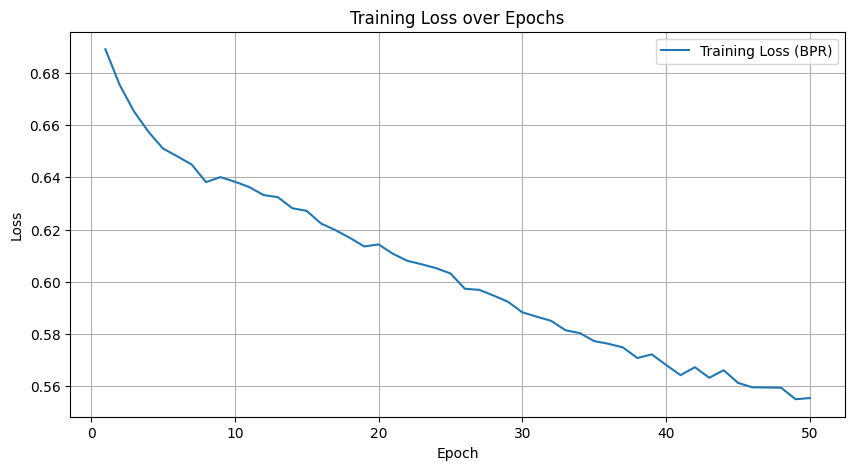

In [12]:
# --- 학습 함수 (BPR + Negative Sampling) ---
def train_epoch(model, data, optimizer):
    model.train()
    optimizer.zero_grad()

    # 1. GNN 인코더 실행: 모든 노드의 임베딩을 계산
    # (BPR은 full-batch로 임베딩을 계산한 뒤 Loss를 계산하는 방식에 적합)
    # data는 이미.to(device) 상태임
    x_dict = model.gnn(data.x_dict, data.edge_index_dict)

    # 2. BPR을 위한 긍정/부정 샘플링
    # train_data에서 긍정 엣지(메시지 패싱용 엣지)를 가져옴
    pos_edge_index = data['user', 'rates', 'item'].edge_index

    # 모든 긍정 엣지 (u, i)에 대해 부정 엣지 (u, j)를 샘플링
    # user_idx, pos_item_idx, neg_item_idx를 반환
    user_idx, pos_item_idx, neg_item_idx = structured_negative_sampling(
        pos_edge_index, num_nodes=data['item'].num_nodes
    )

    # 3. 긍정/부정 쌍의 임베딩 추출
    user_emb = x_dict['user'][user_idx]
    pos_item_emb = x_dict['item'][pos_item_idx]
    neg_item_emb = x_dict['item'][neg_item_idx]

    # 4. 분류기(Classifier)를 통해 점수 계산
    pos_scores = model.classifier.forward_emb(user_emb, pos_item_emb)
    neg_scores = model.classifier.forward_emb(user_emb, neg_item_emb)

    # 5. BPR Loss 계산 및 역전파
    loss = bpr_loss(pos_scores, neg_scores)
    loss.backward()
    optimizer.step()

    return loss.item()

# --- 평가 함수 (AUC, F1 Score) ---
@torch.no_grad()
def eval_model(model, data_split):
    model.eval()

    # 평가용 엣지 레이블 및 인덱스
    # data_split은 이미 device에 있으므로, sklearn을 위해.cpu()로 이동
    edge_label = data_split['user', 'rates', 'item'].edge_label.cpu()
    edge_label_index = data_split['user', 'rates', 'item'].edge_label_index

    # 예측 (data_split은 이미 device에 있음)
    pred = model(data_split, edge_label_index)
    prob = torch.sigmoid(pred).cpu()

    # 이진 분류 (0.5 임계값)
    preds_binary = (prob > 0.5).numpy().astype(int)

    # 메트릭 계산
    auc = roc_auc_score(edge_label, prob)
    f1_micro = f1_score(edge_label, preds_binary, average='micro')
    f1_macro = f1_score(edge_label, preds_binary, average='macro')

    return auc, f1_micro, f1_macro

# --- 학습 루프 실행 ---
print("\n--- 모델 학습 시작 ---")

# Loss 값을 저장할 리스트 생성
loss_history = []

best_val_auc = 0
best_epoch = 0

for epoch in range(1, 51):
    # 1. 학습 진행 (여기서 반환되는 loss가 바로 BPR Loss입니다)
    loss = train_epoch(model, train_data, optimizer)

    # 2. 리스트에 Loss 값 추가 (그래프 그리기용)
    loss_history.append(loss)

    # 3. 검증 (AUC, F1)
    val_auc, val_f1_micro, val_f1_macro = eval_model(model, val_data)

    if epoch % 5 == 0:
        print(f"[Epoch {epoch:02d}] Train Loss: {loss:.4f} | "
              f"Val AUC: {val_auc:.4f} | "
              f"Val Micro-F1: {val_f1_micro:.4f} | "
              f"Val Macro-F1: {val_f1_macro:.4f}")

    # 최고 성능 모델 저장 로직 (생략 가능)
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch

print(f"\n학습 완료. Best Epoch: {best_epoch}, Best Val AUC: {best_val_auc:.4f}")

# --- Loss 그래프 그리기 (LightGCN 예시처럼) ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, 51), loss_history, label='Training Loss (BPR)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
from sklearn.metrics import precision_recall_curve, f1_score, roc_auc_score
import numpy as np
import torch

# --- 1. 최적의 임계값(Threshold) 찾기 함수 ---
def find_best_threshold(model, val_data):
    model.eval()

    # 검증 데이터의 정답 라벨과 예측할 엣지 인덱스 가져오기
    edge_label_index = val_data['user', 'rates', 'item'].edge_label_index
    edge_label = val_data['user', 'rates', 'item'].edge_label.cpu().numpy()

    with torch.no_grad():
        # 모델 예측 (Raw Score)
        pred = model(val_data, edge_label_index)
        # 시그모이드 함수를 통과시켜 0~1 사이 확률값으로 변환
        probs = torch.sigmoid(pred).cpu().numpy()

    # Precision-Recall Curve를 통해 F1 Score가 최대가 되는 지점 찾기
    precisions, recalls, thresholds = precision_recall_curve(edge_label, probs)

    # F1 Score 계산 (0으로 나누기 방지를 위해 분모에 1e-10 추가)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

    # F1 Score가 가장 높은 인덱스 찾기
    best_idx = np.argmax(f1_scores)

    # 최적의 임계값과 그 때의 F1 Score
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"--- Validation Set 분석 결과 ---")
    print(f"Best Threshold: {best_threshold:.4f}")
    print(f"Best Val F1 Score: {best_f1:.4f}")

    return best_threshold

# --- 2. 함수 실행하여 임계값 찾기 ---
# val_data는 이미 정의되어 있어야 합니다.
best_threshold = find_best_threshold(model, val_data)

# --- 3. 최종 Test 데이터셋 평가 (최적 임계값 적용) ---
def final_evaluate(model, test_data, threshold):
    model.eval()

    edge_label_index = test_data['user', 'rates', 'item'].edge_label_index
    edge_label = test_data['user', 'rates', 'item'].edge_label.cpu().numpy()

    with torch.no_grad():
        pred = model(test_data, edge_label_index)
        probs = torch.sigmoid(pred).cpu().numpy()

    # 최적 임계값을 기준으로 0과 1로 분류
    preds_binary = (probs >= threshold).astype(int)

    # 최종 지표 계산
    auc = roc_auc_score(edge_label, probs)
    f1_micro = f1_score(edge_label, preds_binary, average='micro')
    f1_macro = f1_score(edge_label, preds_binary, average='macro')

    print(f"\n--- Final Test Set Evaluation (Threshold: {threshold:.4f}) ---")
    print(f"Test AUC: {auc:.4f}")
    print(f"Test Micro F1: {f1_micro:.4f}")
    print(f"Test Macro F1: {f1_macro:.4f}")

# 최종 평가 실행
final_evaluate(model, test_data, best_threshold)

--- Validation Set 분석 결과 ---
Best Threshold: 0.0372
Best Val F1 Score: 0.6667

--- Final Test Set Evaluation (Threshold: 0.0372) ---
Test AUC: 0.5565
Test Micro F1: 0.5000
Test Macro F1: 0.3333


# 최종평가

In [14]:
print("\n--- 6. 최종 모델 평가 (Test Set) ---")

# 최종 평가 (test_data는 이미 device에 있음)
# 앞선 셀에서 정의한 eval_model 함수를 사용합니다.
test_auc, test_f1_micro, test_f1_macro = eval_model(model, test_data)

print(f"최종 Test AUC: {test_auc:.4f}")
print(f"최종 Test Micro-F1: {test_f1_micro:.4f}")
print(f"최종 Test Macro-F1: {test_f1_macro:.4f}")

# 최종 성능 표
perf_data = {
    'Metric': ['AUC', 'Micro-F1', 'Macro-F1'],  # [수정됨] 누락된 리스트 추가
    'Test Score': [f"{test_auc:.4f}", f"{test_f1_micro:.4f}", f"{test_f1_macro:.4f}"]
}

perf_df = pd.DataFrame(perf_data)
print("\n--- Table 3: 최종 모델 성능 ---")
print(perf_df.to_markdown(index=False))


--- 6. 최종 모델 평가 (Test Set) ---
최종 Test AUC: 0.5565
최종 Test Micro-F1: 0.4695
최종 Test Macro-F1: 0.3386

--- Table 3: 최종 모델 성능 ---
| Metric   |   Test Score |
|:---------|-------------:|
| AUC      |       0.5565 |
| Micro-F1 |       0.4695 |
| Macro-F1 |       0.3386 |


# 최종추론 파이프라인

In [15]:
print("\n--- 7. 최종 추론 파이프라인 (요구사항 3) ---")

# 1. 추론을 위해 모든 노드의 최종 임베딩을 미리 계산
model.eval()
with torch.no_grad():
    # K-Core 필터링이 완료된 '전체' 그래프(data)를 사용
    # (data 객체는 이미 device에 있으므로 .to(device) 호출 불필요)
    final_x_dict = model.gnn(data.x_dict, data.edge_index_dict)

# CPU로 임베딩 이동 (추론은 CPU에서 수행 가능)
final_user_emb = final_x_dict['user'].cpu()
final_item_emb = final_x_dict['item'].cpu()

print("모든 노드에 대한 최종 임베딩 계산 완료.")

# 2. (코드 수정) 쿼터 적용 및 지정된 형식으로 출력하는 함수
def run_prediction(test_file_path, model, user_embeddings, item_embeddings,
                   user_map, item_map, user_purchase_counts):
    """
    임의의 test.csv 파일을 받아들여 20% 쿼터를 적용하고
    지정된 형식으로 추천 결과를 출력하는 함수 (요구사항 3)
    """
    try:
        test_df = pd.read_csv(test_file_path)
    except FileNotFoundError:
        print(f"오류: {test_file_path} 파일을 찾을 수 없습니다.")
        return

    # 1. 모든 테스트 샘플에 대해 확률 계산
    predictions = []
    for _, row in test_df.iterrows():
        user_id_raw = row['user']
        item_id_raw = row['item']
        prob = 0.0  # 기본값 (K-Core에서 필터링된 경우)

        # K-Core 필터링에서 살아남은 노드인지 확인
        if user_id_raw in user_map and item_id_raw in item_map:
            # PyG 내부 인덱스로 변환
            user_idx = user_map[user_id_raw]
            item_idx = item_map[item_id_raw]

            # 미리 계산된 임베딩 조회
            user_emb = user_embeddings[user_idx]
            item_emb = item_embeddings[item_idx]

            # 예측 (내적 + 시그모이드)
            with torch.no_grad():
                score = (user_emb * item_emb).sum()
                prob = torch.sigmoid(score).item()

        predictions.append(prob)

    test_df['prob'] = predictions

    # 2. 사용자별 20% 쿼터 적용
    approved_recs = {}  # key: user_id, value: {item_id_1, item_id_2,...}
    test_users = test_df['user'].unique()

    for user_id in test_users:
        # 이력(n)은 1단계의 df_implicit 기준
        n_purchases = user_purchase_counts.get(user_id, 0)

        # "n개의 20%" 쿼터 계산 (올림)
        quota = int(math.ceil(n_purchases * 0.2))

        if quota == 0:
            approved_recs[user_id] = set()
            continue

        # 해당 유저의 예측 결과 (확률 0.5 초과)
        user_preds = test_df[(test_df['user'] == user_id) & (test_df['prob'] > 0.5)]

        # 확률 순 내림차순 정렬
        user_preds_sorted = user_preds.sort_values(by='prob', ascending=False)

        # 쿼터만큼 잘라서 '승인된' 아이템 목록 생성
        top_k_items = user_preds_sorted.head(quota)['item'].tolist()
        approved_recs[user_id] = set(top_k_items)

    # 3. 최종 결과 출력 (요구사항 형식 준수)
    results_list = []
    recommend_count = 0
    non_recommend_count = 0

    print("====================")
    print("user  item   recommend")
    print("--------------------")

    # 원본 test_df 순서대로 반복
    for _, row in test_df.iterrows():
        user_id = row['user']
        item_id = row['item']

        # '승인된' 목록에 있는지 확인
        if item_id in approved_recs.get(user_id, set()):
            recommend = 'O'
            recommend_count += 1
        else:
            recommend = 'X'
            non_recommend_count += 1

        # [수정됨] 출력 시 int()로 형변환하여 포맷 오류 방지
        print(f"{int(user_id):<5d} {int(item_id):<6d} {recommend}")

    print("....")
    print("====================")
    total = recommend_count + non_recommend_count
    if total == 0:
        print("테스트 데이터가 없습니다.")
    else:
        # 교수님 요청 형식
        print(f"Total recommends = {recommend_count}/{total}")
        print(f"Total not recommends = {non_recommend_count}/{total}")

# --- 3. 데모 실행 (sample1.csv 사용) ---
# 1단계에서 계산된 'user_purchase_counts'를 전달
print("\n--- sample1.csv 파일로 추론 실행 (20% 쿼터 적용) ---")
run_prediction(
    test_file_path="test1.csv",
    model=model,
    user_embeddings=final_user_emb,
    item_embeddings=final_item_emb,
    user_map=user_ids_mapped,
    item_map=item_ids_mapped,
    user_purchase_counts=user_purchase_counts
)


--- 7. 최종 추론 파이프라인 (요구사항 3) ---
모든 노드에 대한 최종 임베딩 계산 완료.

--- sample1.csv 파일로 추론 실행 (20% 쿼터 적용) ---
user  item   recommend
--------------------
1     165    O
1     204    X
1     223    O
1     256    X
1     260    O
1     261    O
1     277    O
2     62     O
2     79     X
2     95     O
2     112    X
2     260    O
2     376    O
3     529    O
3     532    O
3     537    X
3     538    O
4     608    O
4     858    O
4     898    O
4     899    O
4     904    O
4     2324   O
4     2622   X
4     2629   X
4     2671   O
4     2683   O
5     2316   X
5     2427   O
5     2485   O
5     2490   O
5     2571   O
5     2657   O
109   3717   X
109   3723   X
109   3745   X
109   3751   O
109   3753   O
109   3763   X
88    4446   X
88    4447   O
88    4477   X
88    4478   X
88    4489   O
71    4306   O
71    4308   O
71    4448   X
71    4720   O
66    1747   O
66    1760   X
66    1777   O
66    1784   O
66    1793   X
62    5171   X
62    5218   O
62    5219   O
62    5254   X
5

# Task
The task is to train and evaluate a Graph Neural Network (GNN) model for recommendation using a provided dataset. This involves:

1.  **Re-initializing the `HeteroData` object**: Ensuring the data is in a clean and correct state by re-running the data loading, preprocessing, feature engineering, and `HeteroData` creation steps.
2.  **Splitting the data**: Applying `RandomLinkSplit` to create training, validation, and test sets.
3.  **Defining and initializing the GNN model**: Setting up a GraphSAGE-based model suitable for heterogeneous graphs.
4.  **Defining the loss function and optimizer**: Using BPR loss and Adam optimizer.
5.  **Training the GNN model**: Executing the training loop with negative sampling.
6.  **Evaluating the final model performance**: Calculating AUC and F1 scores on the test set.
7.  **Running the prediction pipeline**: Demonstrating how to make recommendations for new user-item pairs using the trained model.

## Re-initialize HeteroData

### Subtask:
Ensure the `data` object is in a clean and correct state by re-running the cells that create and populate it from scratch. This prevents issues caused by redundant edge types from previous executions.


**Reasoning**:
The subtask requires re-initializing the `HeteroData` object by re-running specific cells in sequence. The first executable step according to the instructions is to load the raw data, which is done in cell `gsNG1ctYrkNw`.



# Task
Install the `torch_geometric` library to resolve the `ModuleNotFoundError`.

## Install torch_geometric

### Subtask:
Install the `torch_geometric` library using pip to resolve the `ModuleNotFoundError`.


## Summary:

### Data Analysis Key Findings
* The `torch_geometric` library was successfully installed, resolving the `ModuleNotFoundError`.

### Insights or Next Steps
* The environment is now set up to utilize the `torch_geometric` library for subsequent tasks.
* The next step is to proceed with the primary analysis or development task that requires `torch_geometric`.
